In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import acovf
from numpy.linalg import svd

# Problem 1: Housing Price Analysis Revisited

In [2]:
df = pd.read_csv("/kaggle/input/datasets/tommasofacchin/zillow-mitx-proj2/data_zillow_house_prices-proj2.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (893, 277)


,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2021-11-30,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31
0,102001,0,United States,country,NaN,127881.0,128227.0,128591.0,129332.0,130079.0,...,318303.0,322658.0,327381.0,332588.0,337848.0,343392.0,348415.0,352585.0,354986.0,356026.0
1,394913,1,"New York, NY",msa,NY,224676.0,226018.0,227226.0,229604.0,231817.0,...,573600.0,576842.0,580804.0,585445.0,591876.0,599008.0,606525.0,612535.0,616856.0,619142.0
2,753899,2,"Los Angeles, CA",msa,CA,227786.0,228579.0,229794.0,232104.0,234580.0,...,845860.0,855023.0,865646.0,877802.0,895038.0,914016.0,930381.0,931707.0,928599.0,914636.0
3,394463,3,"Chicago, IL",msa,IL,170004.0,170405.0,170924.0,171963.0,173064.0,...,288807.0,291527.0,294162.0,296729.0,300023.0,303490.0,307454.0,310438.0,312286.0,312609.0
4,394514,4,"Dallas, TX",msa,TX,129921.0,130025.0,130112.0,130323.0,130544.0,...,337274.0,343129.0,350514.0,358982.0,367040.0,376487.0,385149.0,392668.0,394861.0,393920.0


## Autocovariance

rho(0) = 1442.88
rho(1) = 1403.7
rho(2) = 1363.79


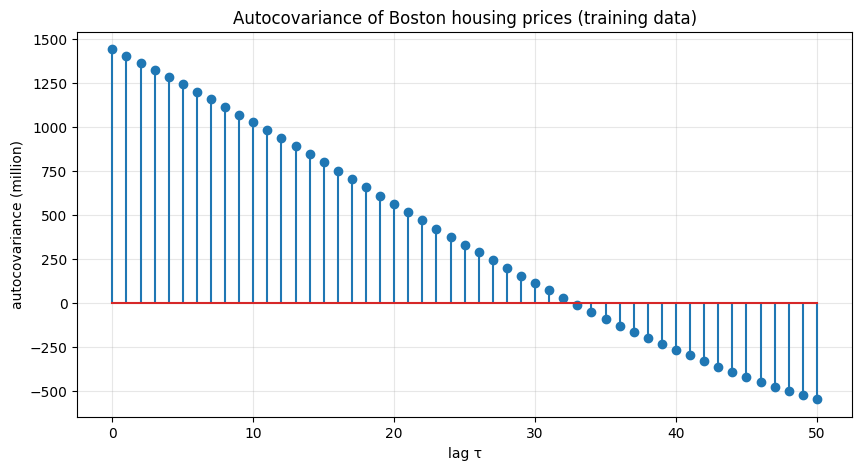

In [3]:
boston = df[df["RegionName"] == "Boston, MA"].copy()

# Keep only date columns
date_cols = [c for c in df.columns if c[:4].isdigit()]
train_cols = [c for c in date_cols if ("2010-01-31" <= c <= "2017-12-31")]

# Build training series
train = boston[train_cols].iloc[0].astype(float).values

# Autocovariance with exact convention required
rho = acovf(train, demean=True, fft=False, adjusted=False)

#  Convert to millions and round to 2 decimals
rho_million = rho / 1e6
rho0 = round(rho_million[0], 2)
rho1 = round(rho_million[1], 2)
rho2 = round(rho_million[2], 2)

print("rho(0) =", rho0)
print("rho(1) =", rho1)
print("rho(2) =", rho2)

# Plot autocovariance for lags 0 to 50
max_lag = 50
rho_lags = acovf(train, demean=True, fft=False, adjusted=False, nlag=max_lag) / 1e6
lags = np.arange(len(rho_lags))

plt.figure(figsize=(10, 5))
plt.stem(lags, rho_lags)
plt.xlabel("lag τ")
plt.ylabel("autocovariance (million)")
plt.title("Autocovariance of Boston housing prices (training data)")
plt.grid(alpha=0.3)
plt.show()

## Hankel Matrix

In [4]:
from numpy.linalg import svd

x = boston[train_cols].iloc[0].astype(float).values
L = 50                     
x = x[:L]
print("L =", len(x))

def hankel_matrix(x, m):
    L = len(x)
    n_cols = L - m + 1
    H = np.zeros((m, n_cols))
    for i in range(m):
        H[i, :] = x[i:i + n_cols]
    return H

def smallest_r_for_m(x, m, thresh=0.99):
    H = hankel_matrix(x, m)
    # SVD: H = U * diag(s) * V^T, s sorted desc
    s = svd(H, compute_uv=False)
    s2 = s**2
    total = s2.sum()
    cum = np.cumsum(s2)
    r_tilde = np.searchsorted(cum, thresh * total) + 1
    return r_tilde

for m in [5, 8, 10]:
    r_tilde = smallest_r_for_m(x, m, thresh=0.99)
    print(f"m = {m}, L = 50 -> r_tilde =", r_tilde)

L = 50
m = 5, L = 50 -> r_tilde = 1
m = 8, L = 50 -> r_tilde = 1
m = 10, L = 50 -> r_tilde = 1


## Retail Data with Multiple Time Series

In [5]:

train = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-walmart/data_walmart_train.csv")
train_missing = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-walmart/data_walmart_train_missing.csv")
test = pd.read_csv("/kaggle/input/datasets/tommasofacchin/mitx-walmart/data_walmart_test.csv")

for df in [train, train_missing, test]:
    df["Date"] = pd.to_datetime(df["Date"])

all_dates = pd.concat([train["Date"], test["Date"]], axis=0)
unique_sorted_dates = all_dates.sort_values().unique()
second_day = unique_sorted_dates[1]
print("Second day overall:", second_day.date())

n_weeks_train = train["Date"].nunique()
print("Number of weeks in train:", n_weeks_train)

n_weeks_test = test["Date"].nunique()
print("Number of weeks in test:", n_weeks_test)

n_cells = train_missing.size
n_missing = train_missing.isna().sum().sum()
print("Missing cells in train_missing:", n_missing, "on total", n_cells)

Second day overall: 2010-02-12
Number of weeks in train: 120
Number of weeks in test: 23
Missing cells in train_missing: 20995 on total 81240


# Problem 2: Page Matrix

In [6]:
s10_d83_full = train["s10_d83"].values
s1_d34_full  = train["s1_d34"].values

print("len s10_d83_full:", len(s10_d83_full))
print("len s1_d34_full :", len(s1_d34_full))

L = 10

def page_matrix(series, L):
    T = len(series)
    T_dash = T // L          
    s_used = series[:T_dash * L]
    P = s_used.reshape((L, T_dash), order="F")
    return P

def smallest_r_for_page(P, thresh=0.99):
    s = svd(P, compute_uv=False)
    s2 = s**2
    total = s2.sum()
    cum = np.cumsum(s2)
    r_tilde = np.searchsorted(cum, thresh * total) + 1
    return r_tilde

# r_tilde with complete data
P10_full = page_matrix(s10_d83_full, L)
P1_full  = page_matrix(s1_d34_full,  L)

r10_full = smallest_r_for_page(P10_full, thresh=0.99)
r1_full  = smallest_r_for_page(P1_full,  thresh=0.99)

print("Store s10_d83 with full data, r_tilde =", r10_full)
print("Store s1_d34 with full data,  r_tilde =", r1_full)

#  Serie with missing data: impute NaN with 0 and normalize
s10_d83_miss = train_missing["s10_d83"].values
s1_d34_miss  = train_missing["s1_d34"].values

s10_d83_miss = np.nan_to_num(s10_d83_miss, nan=0.0)
s1_d34_miss  = np.nan_to_num(s1_d34_miss,  nan=0.0)

def normalize(z):
    return (z - np.mean(z)) / np.std(z)

s10_d83_miss_norm = normalize(s10_d83_miss)
s1_d34_miss_norm  = normalize(s1_d34_miss)

P10_miss = page_matrix(s10_d83_miss_norm, L)
P1_miss  = page_matrix(s1_d34_miss_norm,  L)

r10_miss = smallest_r_for_page(P10_miss, thresh=0.99)
r1_miss  = smallest_r_for_page(P1_miss,  thresh=0.99)

print("Store s10_d83 with missing data replaced by zeros, r_tilde =", r10_miss)
print("Store s1_d34 with missing data replaced by zeros, r_tilde =", r1_miss)

len s10_d83_full: 120
len s1_d34_full : 120
Store s10_d83 with full data, r_tilde = 4
Store s1_d34 with full data,  r_tilde = 3
Store s10_d83 with missing data replaced by zeros, r_tilde = 8
Store s1_d34 with missing data replaced by zeros, r_tilde = 8


In [7]:
L = 10
r_tilde = 5

def page_matrix(series, L):
    T = len(series)
    T_dash = T // L
    s_used = series[:T_dash * L]
    P = s_used.reshape((L, T_dash), order="F")
    return P, T_dash, s_used

def impute_series(col_name):
    y_full = train[col_name].values
    y_miss = train_missing[col_name].values

    miss_mask = np.isnan(y_miss)
    
    y_fill = np.nan_to_num(y_miss, nan=0.0)

    # Page matrix
    P, T_dash, y_used = page_matrix(y_fill, L)

    # SVD
    U, s, Vt = svd(P, full_matrices=False)
    s_thresh = np.zeros_like(s)
    s_thresh[:r_tilde] = s[:r_tilde]
    P_hat = U @ np.diag(s_thresh) @ Vt

    y_hat_used = P_hat.reshape((L * T_dash,), order="F")
    y_hat = np.zeros_like(y_fill)
    y_hat[:L * T_dash] = y_hat_used
    if L * T_dash < len(y_hat):
        y_hat[L * T_dash:] = y_fill[L * T_dash:]

    # MSE only on missing
    se = (y_hat[miss_mask] - y_full[miss_mask])**2
    mse = se.mean()
    mse_million = round(mse / 1e6, 2)
    return mse_million

mse_s10_d83 = impute_series("s10_d83")
mse_s1_d34  = impute_series("s1_d34")

print("For store s10_d83, MSE (million) =", mse_s10_d83)
print("For store s1_d34, MSE (million)  =", mse_s1_d34)

For store s10_d83, MSE (million) = 0.12
For store s1_d34, MSE (million)  = 124.27
